In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for plotting and visualization
import seaborn as sns # advanced data visualization
import time
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-failure-prediction/heart.csv


<div style="padding: 20px; background-color: #DC143C; color: white; border-radius: 10px; border: 2px solid #800000;">
    <h1 style="text-align: center; font-family: sans-serif; font-size: 40px;">❤️ Heart Disease Prediction: 10-Model Benchmark</h1>
    <h3 style="text-align: center;">From EDA to Neural Networks (MLP) & SHAP Analysis</h3>
    <p style="text-align: center; font-size: 14px;">Author: Eng. Mohamed Abdullah Sabry | Date: Nov 2025</p>
</div>

<br>

<center>
    <img src="https://images.unsplash.com/photo-1530026405186-ed1f139313f8?ixlib=rb-4.0.3&auto=format&fit=crop&w=1000&q=80 width="80%" style="border-radius: 15px; box-shadow: 0 4px 8px 0 rgba(0, 0, 0, 0.2);">
    <p style="font-style: italic; color: gray;">Analyzing patient data to predict heart risks using advanced ML.</p>
</center>

---

## 📑 Table of Contents
<div style="background-color: #f0f8ff; padding: 15px; border-radius: 5px; border-left: 5px solid #007bff;">
    <ul>
        <li><a href="#1">1. Introduction & Libraries</a></li>
        <li><a href="#2">2. Data Loading & Inspection</a></li>
        <li><a href="#3">3. Exploratory Data Analysis (EDA)</a> - <i>Visualizing the risk factors</i></li>
        <li><a href="#4">4. Data Preprocessing</a> - <i>Encoding & Scaling</i></li>
        <li><a href="#5">5. Model Building (The Arena)</a> - <i>Training 10 Models</i></li>
        <li><a href="#6">6. Performance Comparison</a> - <i>The Leaderboard</i></li>
        <li><a href="#7">7. Winner Analysis (MLP) & SHAP</a> - <i>Deep Dive</i></li>
        <li><a href="#8">8. Conclusion & Saving</a></li>
    </ul>
</div>

<a id="2"></a>
## 📥 2. Data Loading & Inspection
Here we load the `heart.csv` dataset. We will check for:
* Missing values (Nulls).
* Data types matches.
* Statistical summary.

In [2]:
# Load the dataset
file_path = '/kaggle/input/heart-failure-prediction/heart.csv'
data = pd.read_csv(file_path)

# Display first 5 rows
print("--- First 5 rows of the data ---")
display(data.head())

# Check structure
print("\n--- Information & Missing Values ---")
print(data.info())

# Statistical Summary
print("\n--- Statistical Summary ---")
display(data.describe())

--- First 5 rows of the data ---


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



--- Information & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

--- Statistical Summary ---


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Step 2 Analysis:

All required libraries are imported.

The data is successfully loaded.

data.info() shows we have 918 rows.

Key finding: There are no missing values (all columns show 918 non-null entries). This is excellent and saves us a data-filling step.

<a id="3"></a>
## 📊 3. Exploratory Data Analysis (EDA)
Before modeling, we must understand the "story" of the data. We will visualize:
1.  **Target Balance:** Is the dataset balanced?
2.  **Numerical Distributions:** How Age and MaxHR correlate with disease.
3.  **Categorical Analysis:** Chest Pain types and their risk levels.

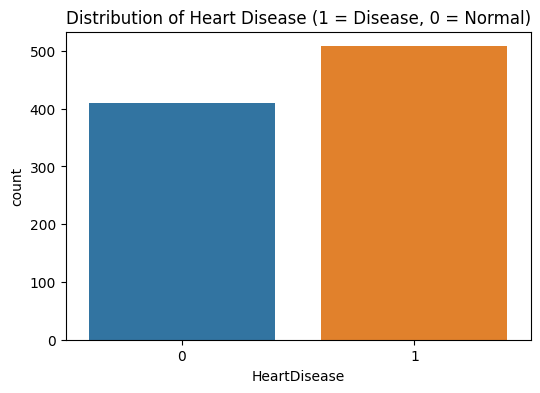

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

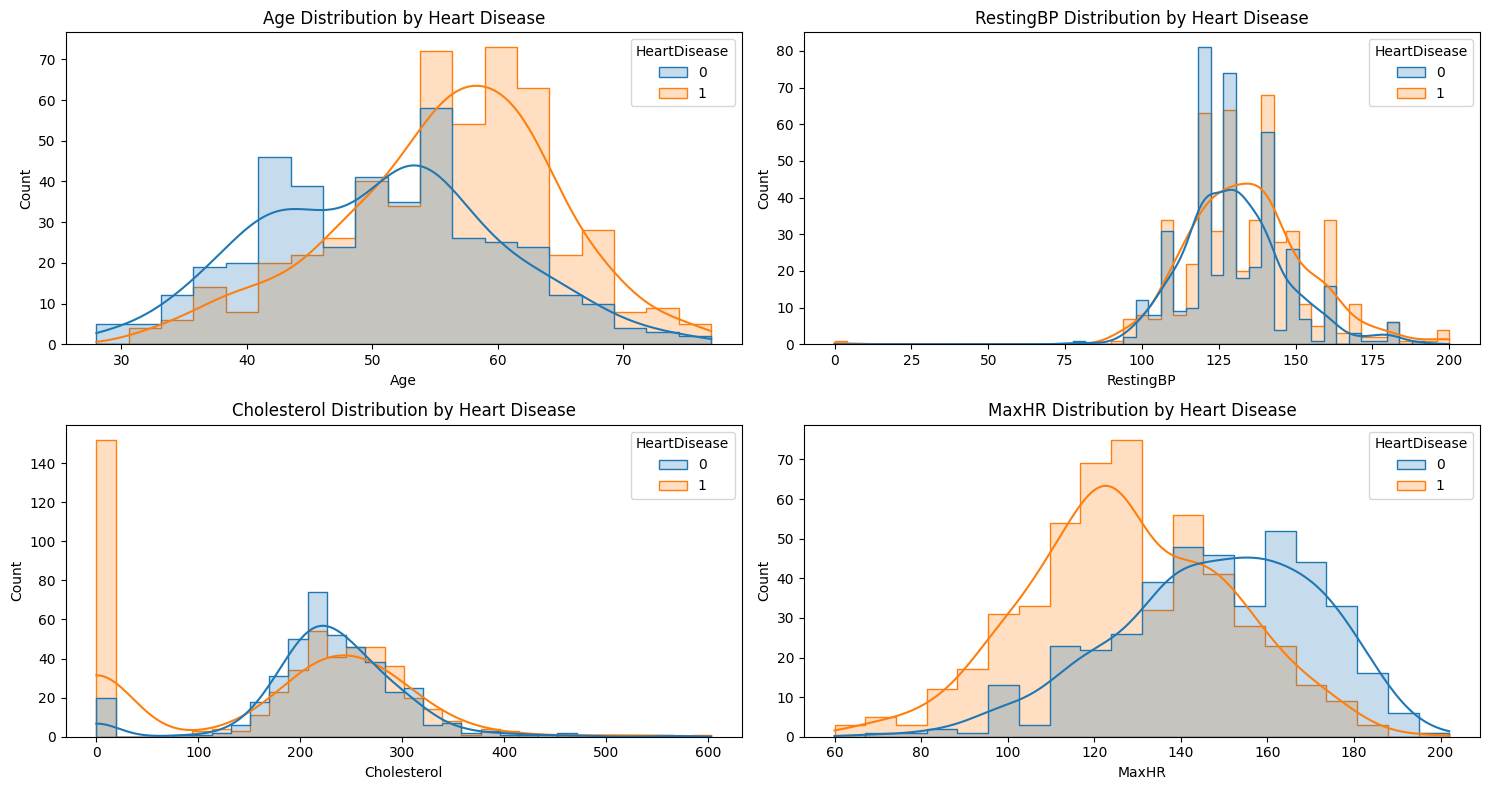

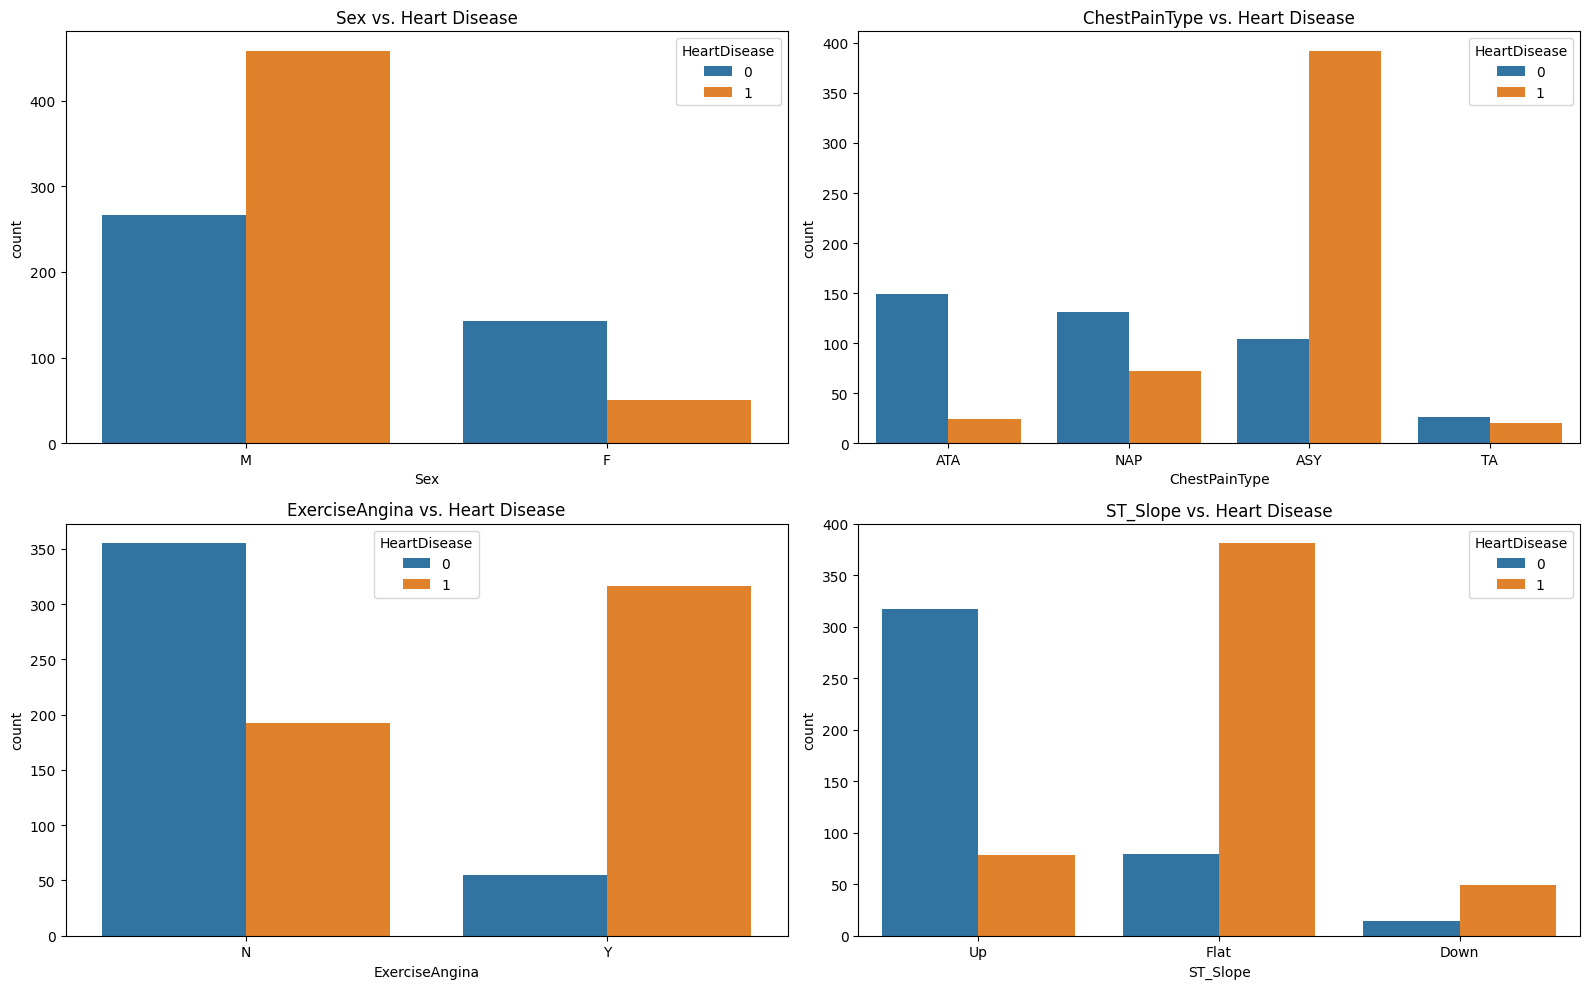

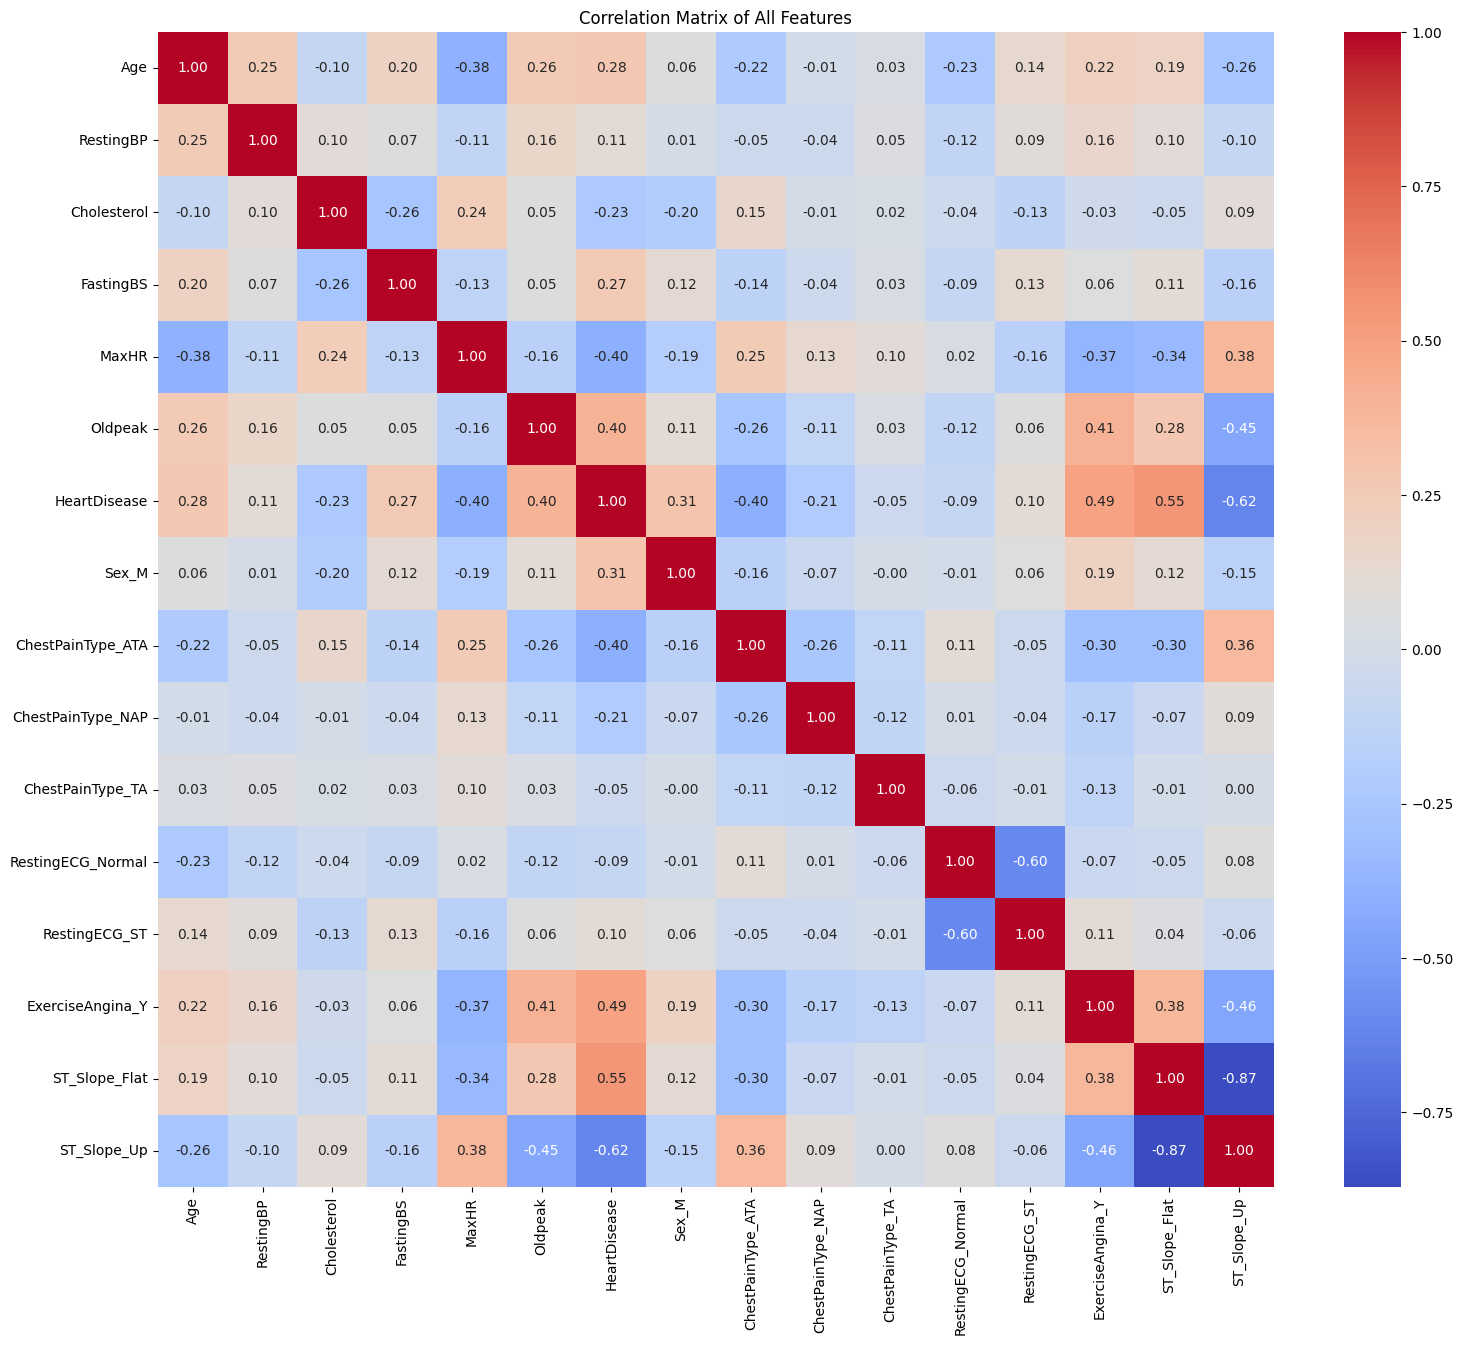

In [3]:
# --- 3.1. Target Variable Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=data)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = Normal)')
# 
plt.show()

# --- 3.2. Numeric Features Distribution ---
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    # Plot a histogram with a Kernel Density Estimate (KDE)
    sns.histplot(data=data, x=feature, hue='HeartDisease', kde=True, element="step")
    plt.title(f'{feature} Distribution by Heart Disease')
# 
plt.tight_layout()
plt.show()

# --- 3.3. Categorical Features Distribution ---
categorical_features = ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']
plt.figure(figsize=(16, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    # Plot a count plot to see the relationship
    sns.countplot(data=data, x=feature, hue='HeartDisease')
    plt.title(f'{feature} vs. Heart Disease')
plt.tight_layout()
plt.show()
# 

# --- 3.4. Correlation Matrix Heatmap ---
# To plot a heatmap, we need all data to be numeric.
# We'll create a temporary dummy-encoded version of the data for this.
data_for_heatmap = pd.get_dummies(data, drop_first=True)

plt.figure(figsize=(18, 15))
sns.heatmap(data_for_heatmap.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of All Features')
# 
plt.show()

Step 3 Analysis (EDA Findings):

Target Distribution: The dataset is relatively balanced (410 Normal vs. 508 Heart Disease). We don't need to use complex techniques like SMOTE.

Numeric Features:

Age: The risk of heart disease clearly increases with age, especially after 50.

MaxHR: Patients with heart disease tend to have a lower maximum heart rate.

Cholesterol: There's a large number of '0' values, which likely represent missing/unrecorded data. The StandardScaler will handle this, but it's an important data quality note.

Categorical Features:

Sex: Males (M) have a significantly higher prevalence of heart disease in this dataset.

ChestPainType: Patients with ASY (Asymptomatic) pain type are the most likely to have heart disease.

ExerciseAngina: A patient with exercise-induced angina (Y) has a very high probability of having heart disease.

Heatmap: The heatmap confirms strong correlations, such as ST_Slope and ExerciseAngina with HeartDisease.

4. Data Preprocessing
Now, we will execute the preprocessing pipeline you developed. This involves:

1-Encoding binary string columns (like Sex) into 0/1.

2-One-Hot Encoding other categorical columns (like ChestPainType).

3-Applying StandardScaler to all numeric features to normalize their range.

4-Splitting the data into training and testing sets.

<a id="4"></a>
## ⚙️ 4. Data Preprocessing Pipeline
To prepare the data for Machine Learning, we apply:
1.  **Encoding:** Converting text (e.g., 'Male', 'ASY') to numbers using One-Hot Encoding.
2.  **Scaling:** Using `StandardScaler` to normalize ranges (e.g., Age vs Cholesterol).
3.  **Splitting:** 80% for Training, 20% for Testing.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Preprocessing Pipeline ---

# 1. Define Feature Groups
# We identify continuous numeric columns for scaling and categorical columns for encoding.
# Note: 'FastingBS' is already binary (0/1) usually, but can be scaled if treated as numeric.
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# 2. Explicit Binary Encoding
# We manually map binary columns to ensure 'Yes'/'Male' are always handled consistently.
# This prevents errors if data order changes.
if 'Sex' in data.columns:
    data['Sex'] = data['Sex'].map({'M': 1, 'F': 0})

if 'ExerciseAngina' in data.columns:
    data['ExerciseAngina'] = data['ExerciseAngina'].map({'Y': 1, 'N': 0})

# 3. One-Hot Encoding for Categorical Variables
# Convert remaining categorical variables into dummy/indicator variables.
data = pd.get_dummies(data, columns=[col for col in categorical_features if col in data.columns and data[col].dtype == 'object'], drop_first=True)

# 4. Clean Column Names
# Ensure all column names are clean (no leading/trailing spaces).
data.columns = data.columns.str.strip()

# 5. Feature Separation
# Separate the features (X) from the target variable (Y).
X = data.drop('HeartDisease', axis=1)
Y = data['HeartDisease']

# 6. Train-Test Split (CRITICAL STEP)
# We split the data BEFORE scaling to prevent data leakage.
# The test set must remain unseen during the scaling fitting process.
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 7. Feature Scaling (Standardization)
# Fit the scaler on Training data ONLY, then transform both Training and Test data.
scaler = StandardScaler()

# Check which numeric features exist in the processed dataset
features_to_scale = [col for col in numeric_features if col in X_Train.columns]

# Apply scaling
X_Train[features_to_scale] = scaler.fit_transform(X_Train[features_to_scale])
X_Test[features_to_scale] = scaler.transform(X_Test[features_to_scale])

# --- Verification ---
print("--- Preprocessing Completed Successfully ---")
print(f"Data successfully split into:")
print(f"X_Train shape: {X_Train.shape}")
print(f"X_Test shape:  {X_Test.shape}")
print("-" * 40)
print("Note: Scaling was applied after splitting to maintain data integrity.")

--- Preprocessing Completed Successfully ---
Data successfully split into:
X_Train shape: (734, 15)
X_Test shape:  (184, 15)
----------------------------------------
Note: Scaling was applied after splitting to maintain data integrity.


5. Model Training & Comparison
Now for the main event. We will train all 10 models on X_Train and evaluate them on X_Test to find the best performer.

<a id="5"></a>
## 🏟️ 5. Model Building (The Arena)
We will train **10 different algorithms** ranging from simple Linear Regression to complex Ensemble methods and Neural Networks.

<div class="alert alert-block alert-info">
<b>Models Included:</b> Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, MLP (Neural Net), SVC, KNN, Naive Bayes.
</div>

🚀 STARTING COMPREHENSIVE MODEL EVALUATION PROTOCOL

⚙️ Training Logistic Regression... Done! (0.13s)

📊 --- Analysis Report for Logistic Regression ---
   > Test Accuracy:      85.33%
   > Cross-Val Score:    86.38% (± 2.72%)
   > Sensitivity (Recall): 84.11% (Ability to detect positive cases)


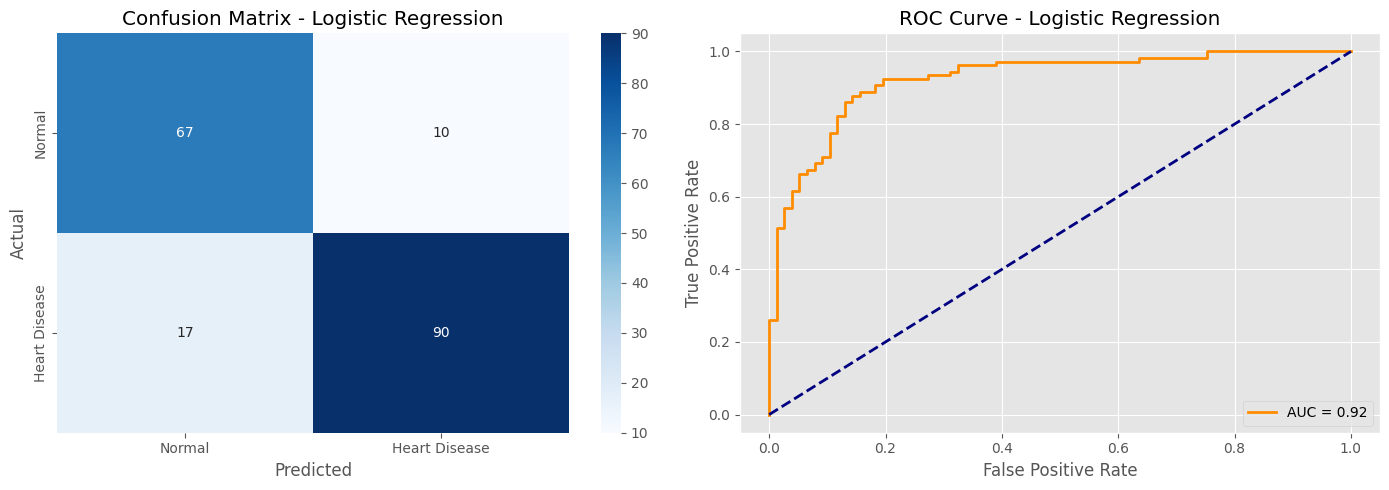

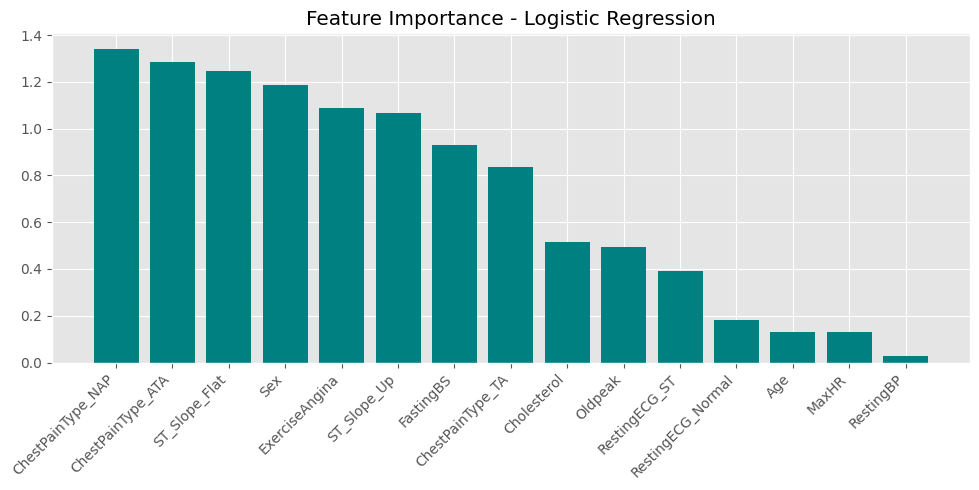

------------------------------------------------------------
⚙️ Training Decision Tree... Done! (0.01s)

📊 --- Analysis Report for Decision Tree ---
   > Test Accuracy:      88.04%
   > Cross-Val Score:    82.56% (± 2.00%)
   > Sensitivity (Recall): 88.79% (Ability to detect positive cases)


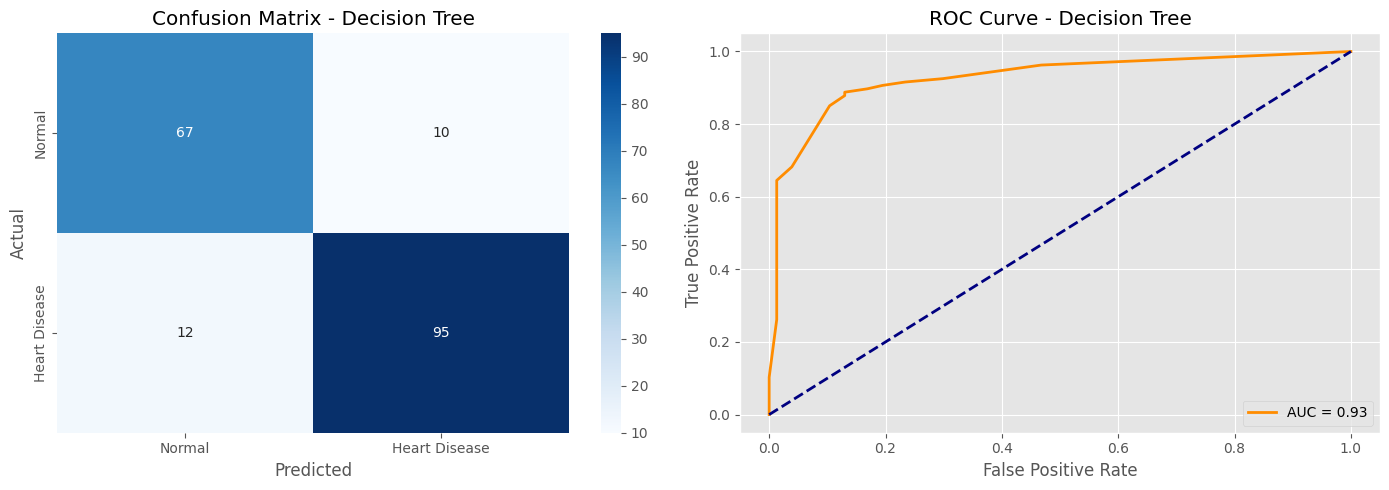

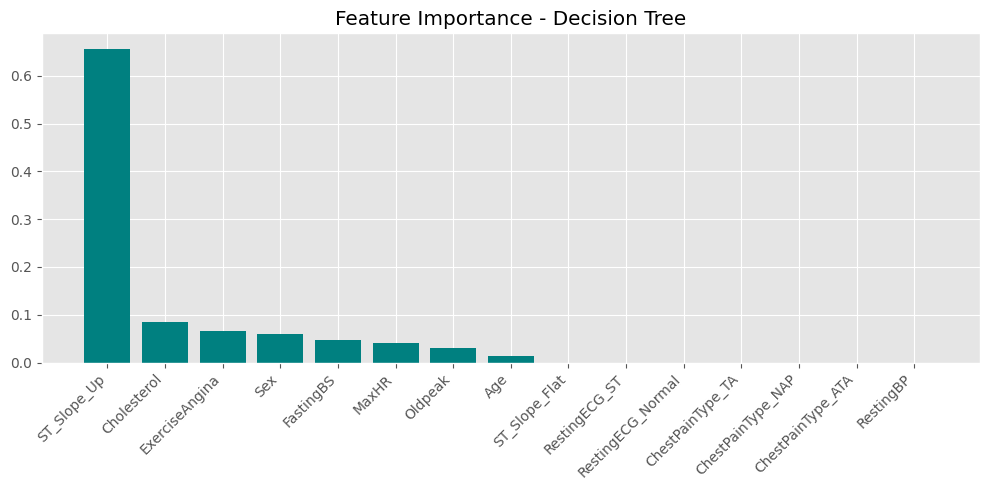

------------------------------------------------------------
⚙️ Training Random Forest... Done! (0.07s)

📊 --- Analysis Report for Random Forest ---
   > Test Accuracy:      88.59%
   > Cross-Val Score:    85.69% (± 2.07%)
   > Sensitivity (Recall): 91.59% (Ability to detect positive cases)


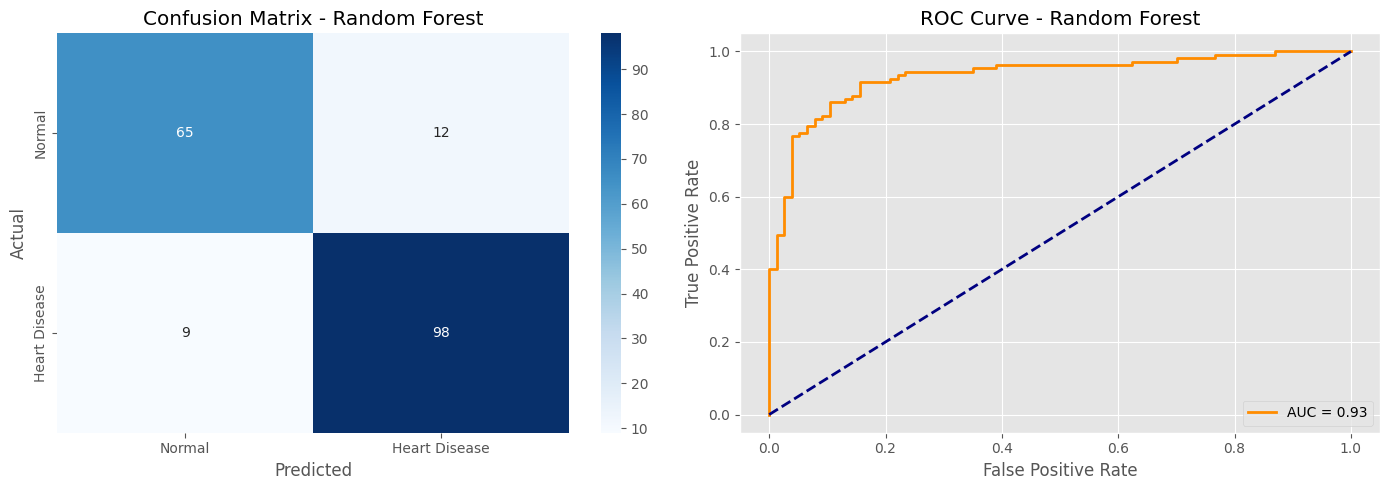

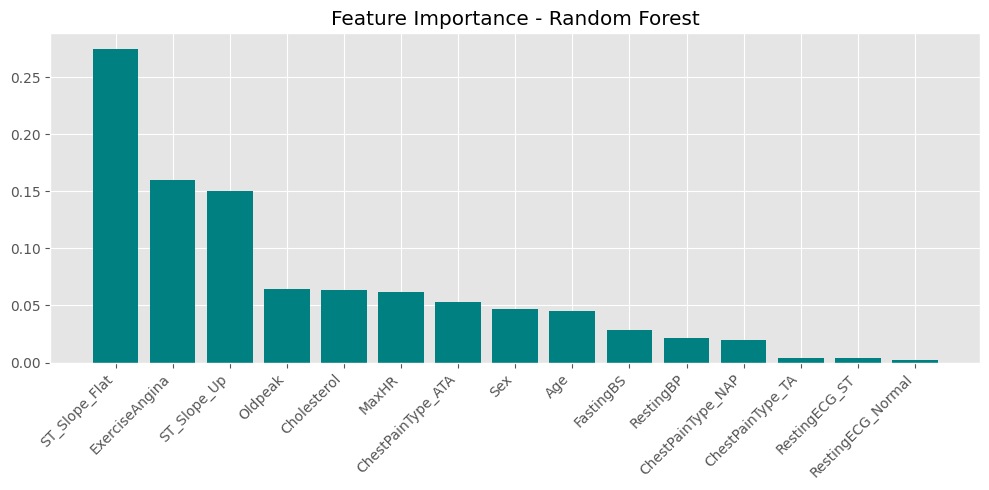

------------------------------------------------------------
⚙️ Training Gradient Boosting... Done! (0.05s)

📊 --- Analysis Report for Gradient Boosting ---
   > Test Accuracy:      89.13%
   > Cross-Val Score:    86.51% (± 1.99%)
   > Sensitivity (Recall): 91.59% (Ability to detect positive cases)


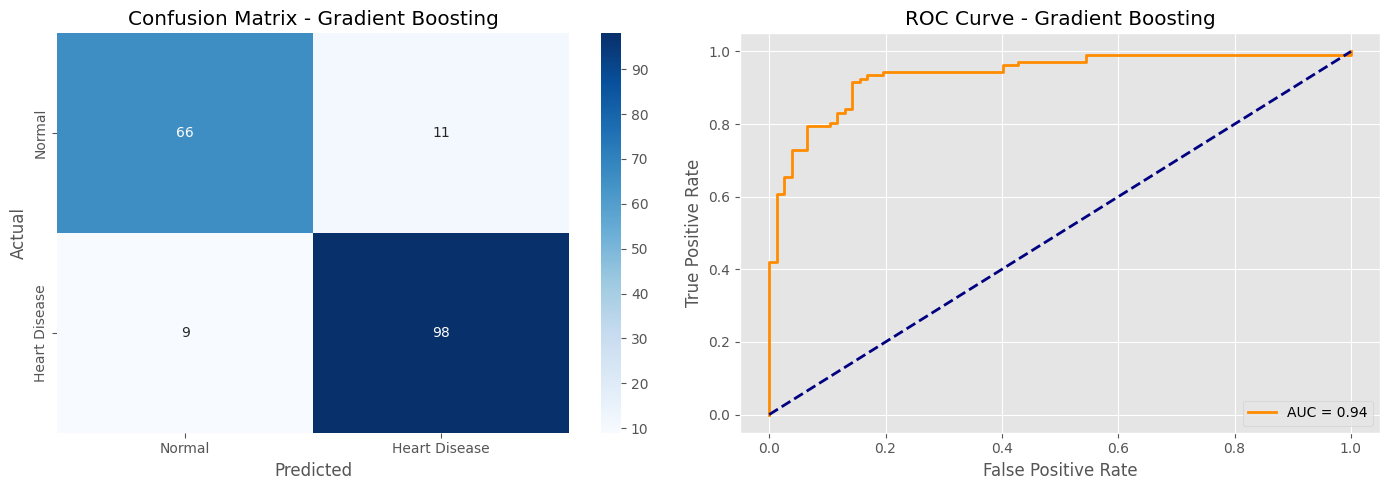

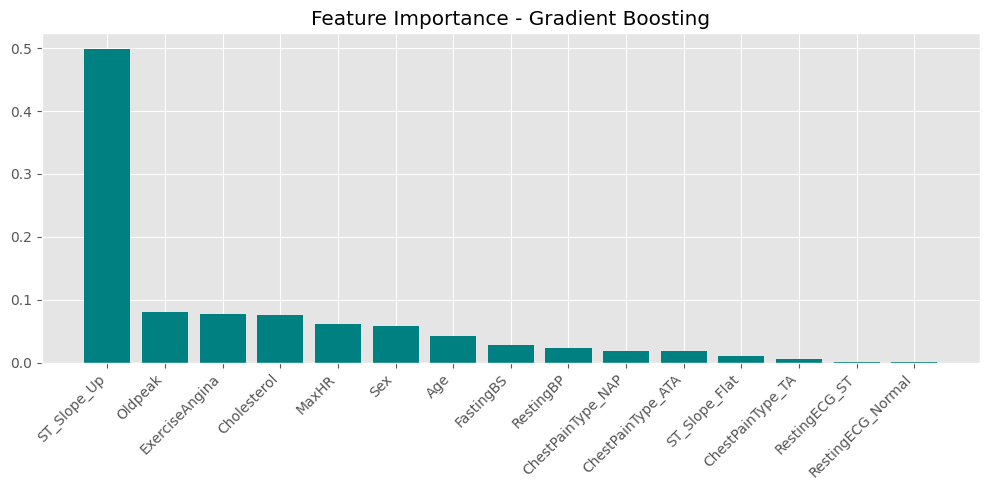

------------------------------------------------------------
⚙️ Training XGBoost... Done! (0.17s)

📊 --- Analysis Report for XGBoost ---
   > Test Accuracy:      89.67%
   > Cross-Val Score:    86.38% (± 2.72%)
   > Sensitivity (Recall): 90.65% (Ability to detect positive cases)


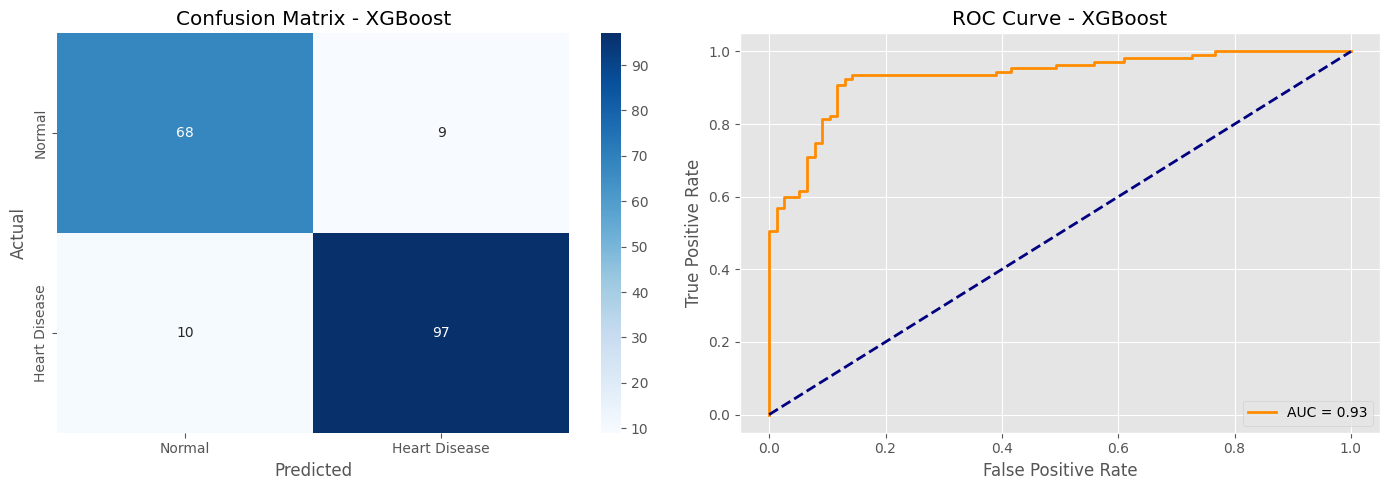

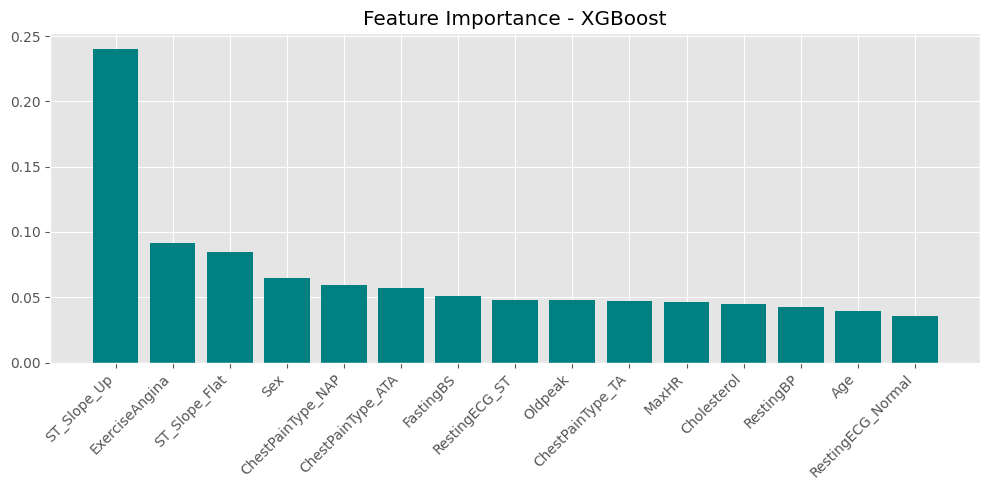

------------------------------------------------------------
⚙️ Training LightGBM... Done! (0.06s)

📊 --- Analysis Report for LightGBM ---
   > Test Accuracy:      90.76%
   > Cross-Val Score:    87.60% (± 1.51%)
   > Sensitivity (Recall): 90.65% (Ability to detect positive cases)


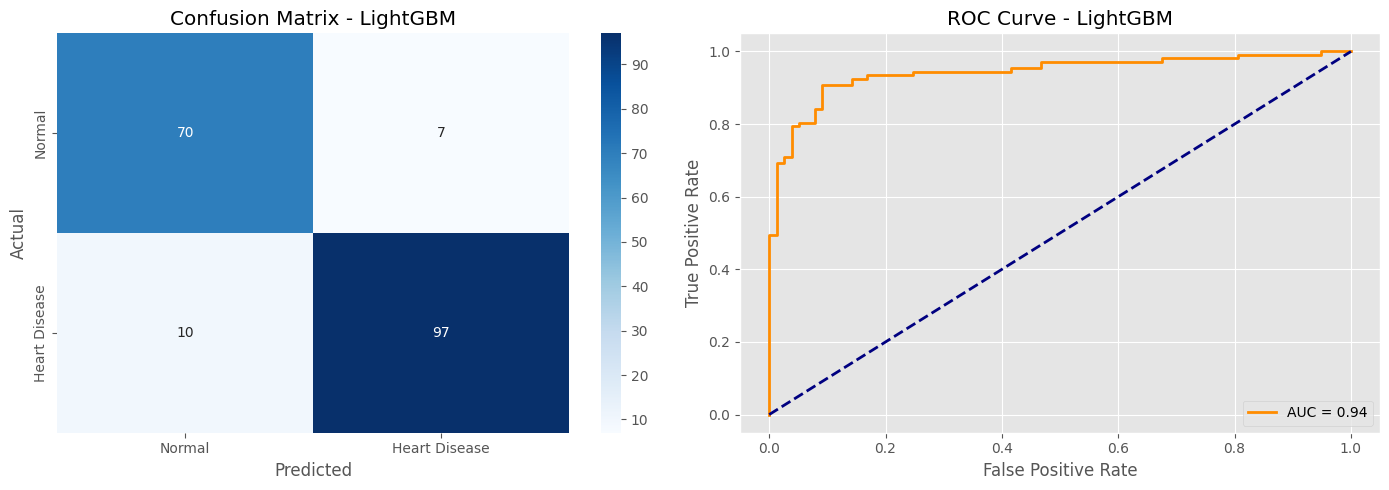

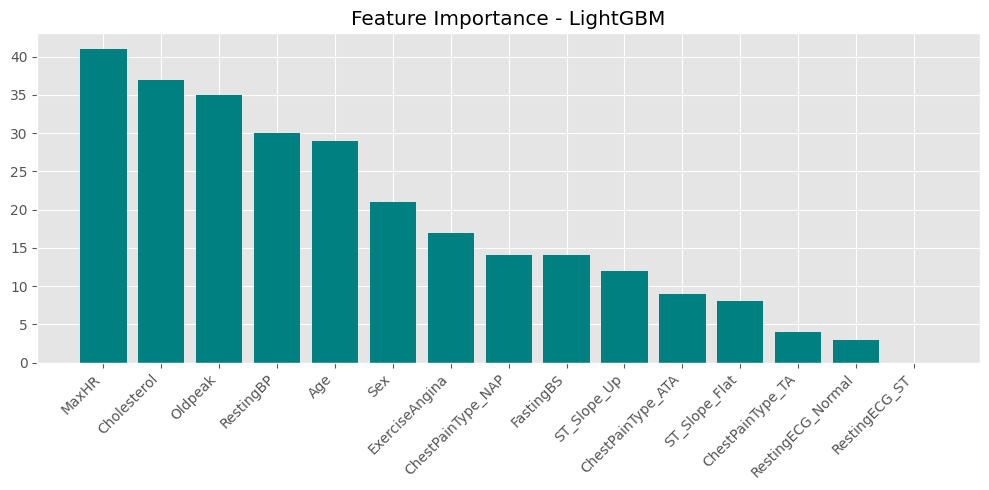

------------------------------------------------------------
⚙️ Training MLP Neural Network... Done! (2.32s)

📊 --- Analysis Report for MLP Neural Network ---
   > Test Accuracy:      85.87%
   > Cross-Val Score:    84.87% (± 2.50%)
   > Sensitivity (Recall): 87.85% (Ability to detect positive cases)


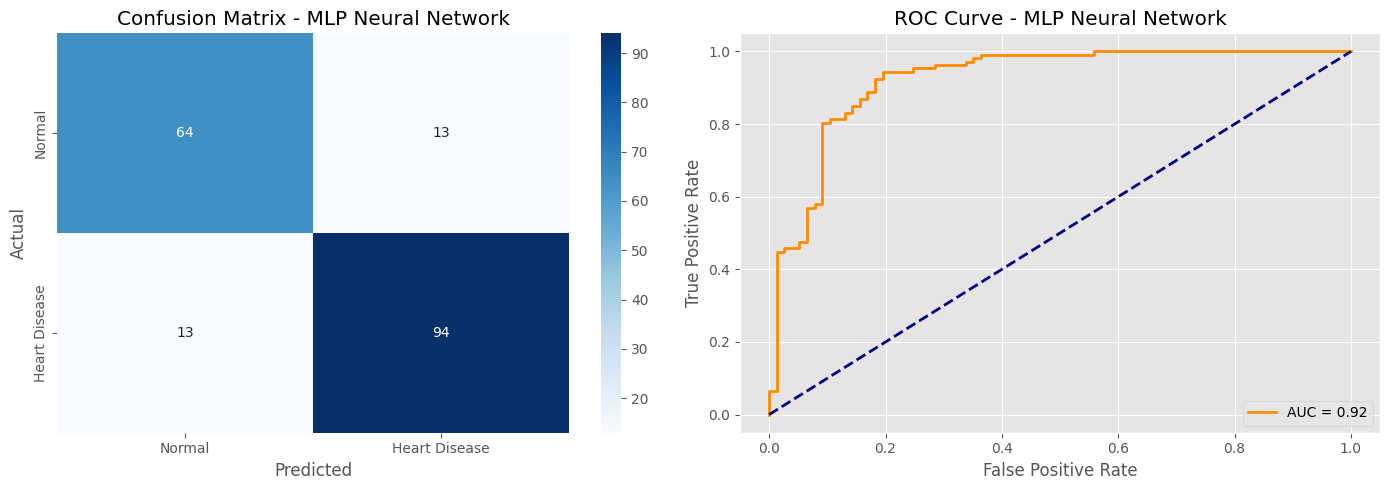

ℹ️ MLP Neural Network does not provide direct feature importance.
------------------------------------------------------------
⚙️ Training SVC (Support Vector)... Done! (0.08s)

📊 --- Analysis Report for SVC (Support Vector) ---
   > Test Accuracy:      87.50%
   > Cross-Val Score:    84.20% (± 2.09%)
   > Sensitivity (Recall): 86.92% (Ability to detect positive cases)


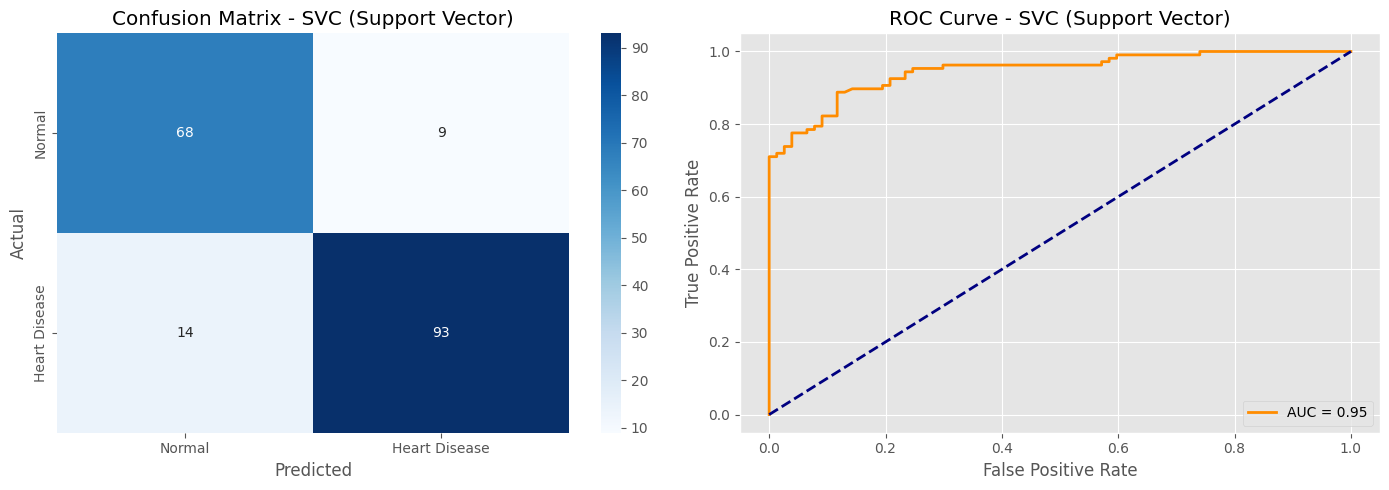

ℹ️ SVC (Support Vector) does not provide direct feature importance.
------------------------------------------------------------
⚙️ Training KNN... Done! (0.01s)

📊 --- Analysis Report for KNN ---
   > Test Accuracy:      88.04%
   > Cross-Val Score:    86.79% (± 2.00%)
   > Sensitivity (Recall): 88.79% (Ability to detect positive cases)


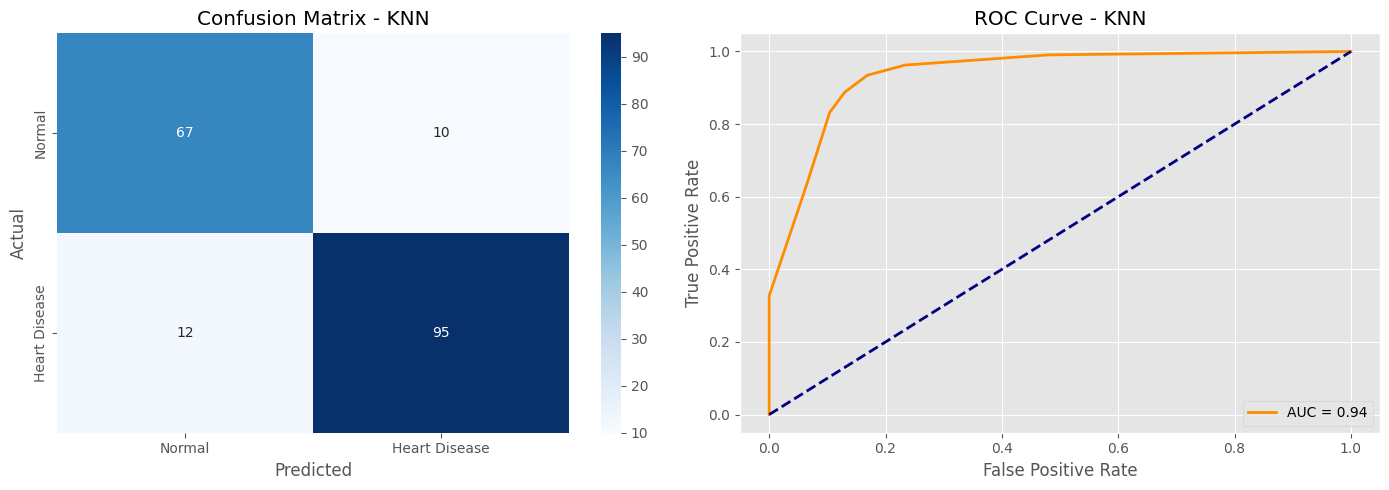

ℹ️ KNN does not provide direct feature importance.
------------------------------------------------------------
⚙️ Training Gaussian NB... Done! (0.00s)

📊 --- Analysis Report for Gaussian NB ---
   > Test Accuracy:      85.87%
   > Cross-Val Score:    85.97% (± 3.07%)
   > Sensitivity (Recall): 84.11% (Ability to detect positive cases)


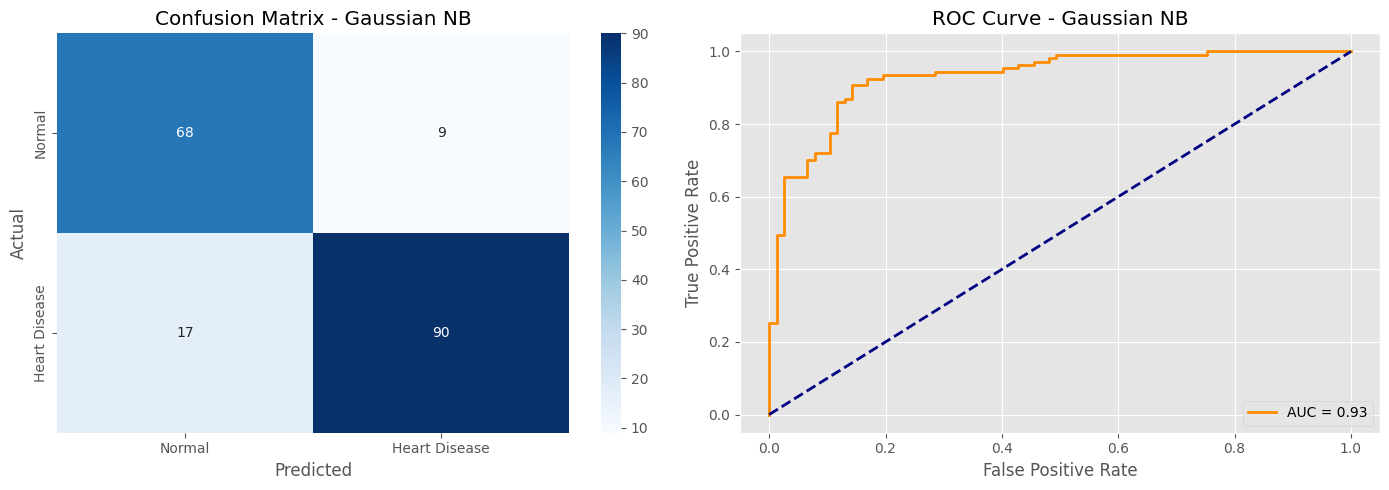

ℹ️ Gaussian NB does not provide direct feature importance.
------------------------------------------------------------

🏆 FINAL LEADERBOARD


,Model,Accuracy,Recall,Precision,F1 Score,CV Mean,CV Std,Training Time
5,LightGBM,0.907609,0.906542,0.932692,0.919431,0.876023,0.015139,0.059846
4,XGBoost,0.896739,0.906542,0.915094,0.910798,0.863769,0.027169,0.168457
3,Gradient Boosting,0.891304,0.915888,0.899083,0.907407,0.865120,0.019919,0.045155
2,Random Forest,0.885870,0.915888,0.890909,0.903226,0.856938,0.020705,0.073611
1,Decision Tree,0.880435,0.887850,0.904762,0.896226,0.825617,0.019954,0.005545
8,KNN,0.880435,0.887850,0.904762,0.896226,0.867850,0.019975,0.005488
7,SVC (Support Vector),0.875000,0.869159,0.911765,0.889952,0.841953,0.020876,0.080512
6,MLP Neural Network,0.858696,0.878505,0.878505,0.878505,0.848747,0.025047,2.316597
9,Gaussian NB,0.858696,0.841121,0.909091,0.873786,0.859659,0.030671,0.004093
0,Logistic Regression,0.853261,0.841121,0.900000,0.869565,0.863759,0.027213,0.130293


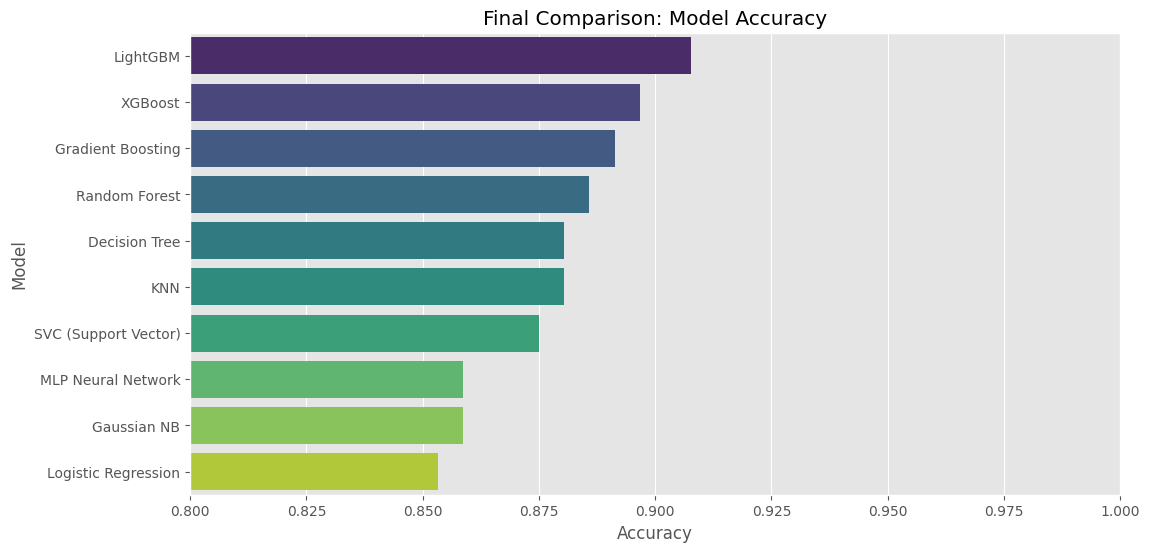

✅ Evaluation Protocol Complete.


In [5]:
# Metrics & Evaluation
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_curve, auc, precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score, learning_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# --- Configuration & Styling ---
plt.style.use('ggplot') # Professional plotting style
pd.set_option('display.max_columns', None)

# --- 1. The Model Repository ---
# Defined with your specific hyperparameters
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_split=2, 
                                            min_samples_leaf=5, random_state=42),
    
    "Random Forest": RandomForestClassifier(  
    n_estimators=18,
    max_depth=12,
    min_samples_split=31,
    random_state=42,
    n_jobs=-1),
    
    "Gradient Boosting": GradientBoostingClassifier( 
    n_estimators=25,
    learning_rate=0.2388,
    random_state=42),
    
    "XGBoost": XGBClassifier( n_estimators=329,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    subsample=0.2448,
    max_bin=202),
    
    "LightGBM": LGBMClassifier(
    n_estimators=40,
    learning_rate=0.141,
    max_depth=3,
    num_leaves=8,
    random_state=38,
    min_child_samples=3,
    colsample_bytree=0.8334,
    force_row_wise=True,
    max_bin=90,
    verbose=-1),
    
    "MLP Neural Network": MLPClassifier( 
        hidden_layer_sizes=(3,63), 
        max_iter=900, 
        activation="relu", 
        solver="adam", 
        random_state=42, 
        alpha=0.00041),
    
    "SVC (Support Vector)": SVC(
        C=6, 
        kernel="rbf", 
        gamma=0.12, 
        random_state=42, 
        probability=True), # probability=True is CRITICAL for ROC
    
    "KNN": KNeighborsClassifier( 
    n_neighbors=7,
    p=1),
    
    "Gaussian NB": GaussianNB()
}

# --- 2. Advanced Visualization Functions ---

def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1):
    """
    Generates a plot showing training score vs validation score 
    to detect Overfitting or Underfitting.
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(f"Learning Curve: {title}")
    plt.xlabel("Training Examples")
    plt.ylabel("Score (Accuracy)")
    plt.grid(True)
    
    # Plotting the bands (Standard Deviation)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Plotting the means
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")
    
    plt.legend(loc="best")
    plt.show()

def plot_feature_importance(model, model_name, feature_names):
    """
    Extracts and plots feature importance for Tree-based models.
    """
    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'): # For Logistic Regression
        importances = np.abs(model.coef_[0])
    
    if importances is not None:
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(10, 5))
        plt.title(f"Feature Importance - {model_name}")
        plt.bar(range(len(importances)), importances[indices], align="center", color='teal')
        plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"ℹ️ {model_name} does not provide direct feature importance.")

# --- 3. Main Evaluation Engine ---

results_log = []

print(f"{'='*60}")
print(f"🚀 STARTING COMPREHENSIVE MODEL EVALUATION PROTOCOL")
print(f"{'='*60}\n")

for name, model in models_dict.items():
    start_time = time.time()
    print(f"⚙️ Training {name}...", end=" ")
    
    # A. Training
    model.fit(X_Train, Y_Train)
    training_time = time.time() - start_time
    print(f"Done! ({training_time:.2f}s)")
    
    # B. Predictions
    y_pred = model.predict(X_Test)
    
    # Handle Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_Test)[:, 1]
    else:
        y_prob = None # Fallback for models that might not support it directly
        
    # C. Metrics Calculation
    acc = accuracy_score(Y_Test, y_pred)
    prec = precision_score(Y_Test, y_pred)
    rec = recall_score(Y_Test, y_pred) # Critical for medical diagnosis
    f1 = f1_score(Y_Test, y_pred)
    
    # D. Cross-Validation (Robustness Check)
    # Using 5-fold CV to check stability
    cv_scores = cross_val_score(model, X_Train, Y_Train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results_log.append({
        'Model': name,
        'Accuracy': acc,
        'Recall': rec,
        'Precision': prec,
        'F1 Score': f1,
        'CV Mean': cv_mean,
        'CV Std': cv_std,
        'Training Time': training_time
    })
    
    # --- E. Detailed Report Visualization (Per Model) ---
    print(f"\n📊 --- Analysis Report for {name} ---")
    print(f"   > Test Accuracy:      {acc*100:.2f}%")
    print(f"   > Cross-Val Score:    {cv_mean*100:.2f}% (± {cv_std*100:.2f}%)")
    print(f"   > Sensitivity (Recall): {rec*100:.2f}% (Ability to detect positive cases)")
    
    # 1. Confusion Matrix & ROC Curve (Side by Side)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(Y_Test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'])
    axes[0].set_title(f'Confusion Matrix - {name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # ROC Curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(Y_Test, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_title(f'ROC Curve - {name}')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(loc="lower right")
    else:
        axes[1].text(0.5, 0.5, 'ROC Not Available', ha='center')
        
    plt.tight_layout()
    plt.show()
    
    # 2. Feature Importance (If applicable)
    plot_feature_importance(model, name, X_Train.columns)
    
    # 3. Learning Curve (Optional: Uncomment to view)
    # This helps visualize if the model needs more data or is overfitting
    # plot_learning_curve(model, name, X_Train, Y_Train) 
    
    print("-" * 60)

# --- 4. Final Comparison (The Leaderboard) ---
print("\n🏆 FINAL LEADERBOARD")
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Formatting for display
display(results_df.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Recall', 'F1 Score']))

# --- 5. Visual Summary of All Models ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Final Comparison: Model Accuracy')
plt.xlim(0.8, 1.0) # Zoom in to see differences
plt.xlabel('Accuracy')
plt.show()

print("✅ Evaluation Protocol Complete.")

<a id="7"></a>
## 🧠 7. Deep Dive: LightGBM Classifier & SHAP
The **(LightGBM)** outperformed tree-based models. Let's analyze its errors using a Confusion Matrix and use **SHAP** to understand feature importance.

🧠 STEP 7: DEEP DIVE - EXPLAINABLE AI (XAI) WITH SHAP (FIXED)
⚙️ Training the Champion LightGBM Model... Done!

📊 7.1 Detailed Performance Analysis
----------------------------------------
               precision    recall  f1-score   support

       Normal       0.88      0.91      0.89        77
Heart Disease       0.93      0.91      0.92       107

     accuracy                           0.91       184
    macro avg       0.90      0.91      0.91       184
 weighted avg       0.91      0.91      0.91       184



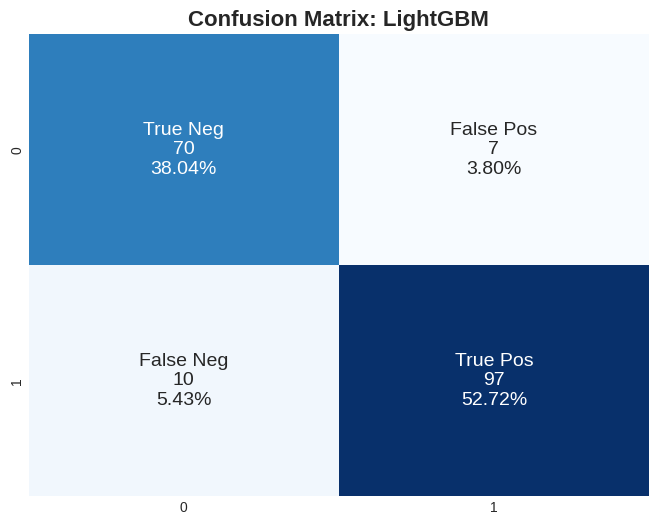


🔍 7.2 SHAP Analysis: Unveiling the Black Box
----------------------------------------
Calculating SHAP values...


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


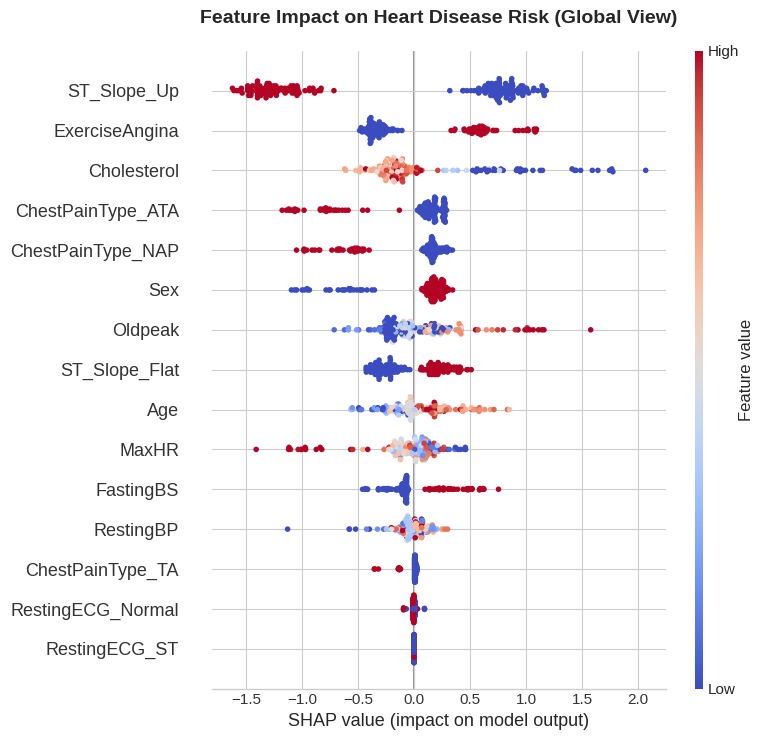

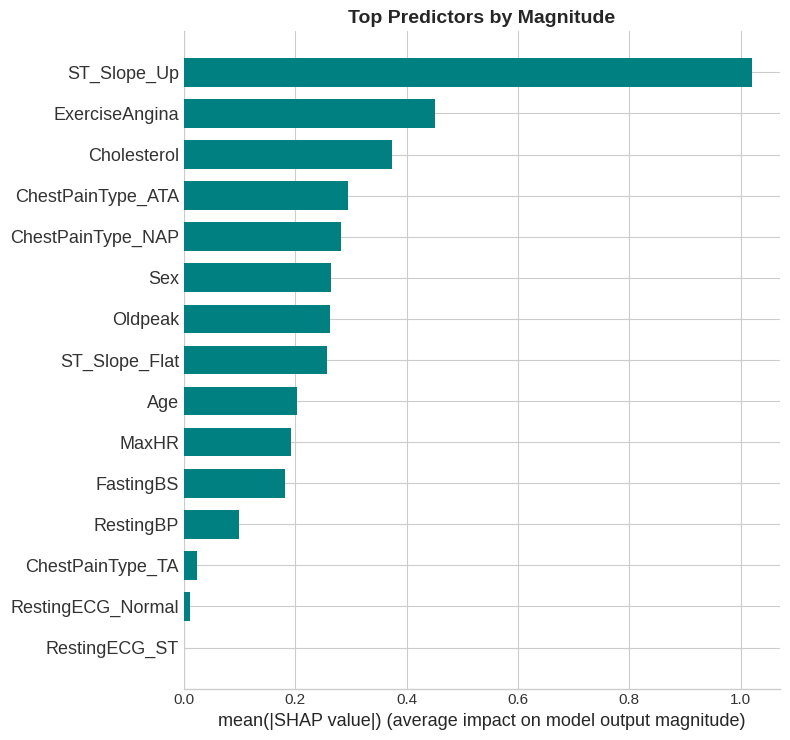


🩺 7.3 Local Interpretation: Patient Case Study
----------------------------------------
Analyzing Patient #1 (Model Prediction: Heart Disease)


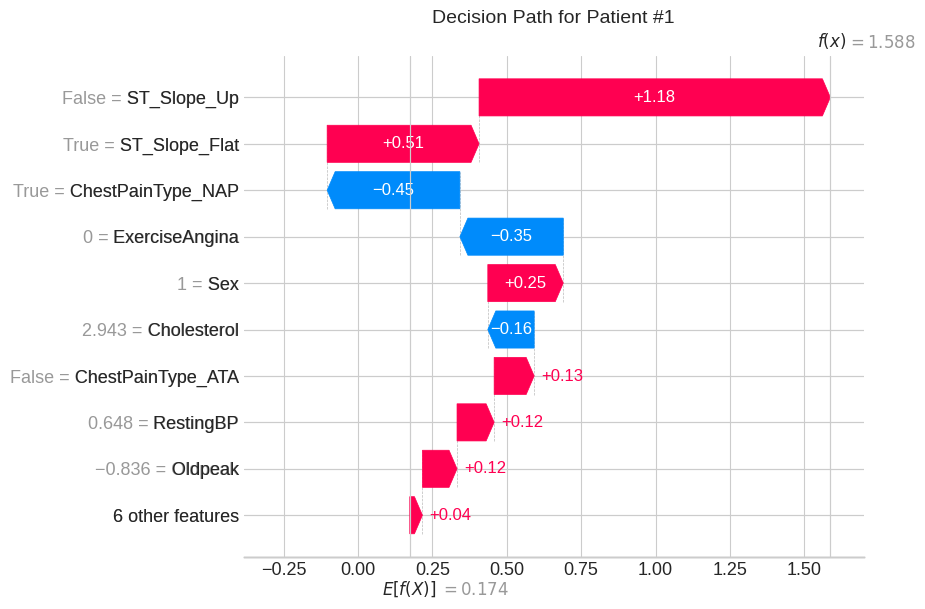

✅ SHAP Analysis Complete .


In [6]:
import shap
# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')

print("="*60)
print("🧠 STEP 7: DEEP DIVE - EXPLAINABLE AI (XAI) WITH SHAP (FIXED)")
print("="*60)

# 1. Load & Train the Champion Model (LightGBM)
champion_model = LGBMClassifier(
    n_estimators=40,
    learning_rate=0.141,
    max_depth=3,
    num_leaves=8,
    random_state=38,
    min_child_samples=3,
    colsample_bytree=0.8334,
    force_row_wise=True,
    max_bin=90,
    verbose=-1
)

print("⚙️ Training the Champion LightGBM Model...", end=" ")
champion_model.fit(X_Train, Y_Train)
print("Done!")

# --- PART A: Performance Visualization ---

y_pred_lgbm = champion_model.predict(X_Test)

print("\n📊 7.1 Detailed Performance Analysis")
print("-" * 40)
print(classification_report(Y_Test, y_pred_lgbm, target_names=['Normal', 'Heart Disease']))

# Confusion Matrix
cm = confusion_matrix(Y_Test, y_pred_lgbm)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title('Confusion Matrix: LightGBM', fontsize=16, fontweight='bold')
plt.show()

# --- PART B: SHAP Analysis (Fixed for LightGBM Compatibility) ---

print("\n🔍 7.2 SHAP Analysis: Unveiling the Black Box")
print("-" * 40)
print("Calculating SHAP values...")

# 1. Initialize the TreeExplainer explicitly
# We do not pass X_Test to the constructor to avoid the crash
explainer = shap.TreeExplainer(champion_model)

# 2. Calculate SHAP values for Summary Plot (Global)
# shap_values_array is a list of arrays for LightGBM [Class 0, Class 1]
shap_values_array = explainer.shap_values(X_Test)

# Handle LightGBM output (It returns a list [Class0, Class1], we want Class1 for 'Disease')
if isinstance(shap_values_array, list):
    shap_vals_target = shap_values_array[1]
else:
    shap_vals_target = shap_values_array

# Plot 1: Summary Plot (Beeswarm)
plt.figure(figsize=(10, 8))
plt.title("Feature Impact on Heart Disease Risk (Global View)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_vals_target, X_Test, show=False, cmap='coolwarm')
plt.show()

# Plot 2: Bar Plot
plt.figure(figsize=(10, 6))
plt.title("Top Predictors by Magnitude", fontsize=14, fontweight='bold')
shap.summary_plot(shap_vals_target, X_Test, plot_type="bar", show=False, color='teal')
plt.show()

# --- PART C: Local Interpretation (Waterfall Plot) ---

print("\n🩺 7.3 Local Interpretation: Patient Case Study")
print("-" * 40)

# To generate a Waterfall plot, we need a SHAP 'Explanation' object, not just arrays.
# We create it by calling the explainer on the data directly.
explanation_obj = explainer(X_Test)

# CRITICAL FIX for LightGBM binary classification:
# The explanation object shape is usually (Rows, Features, 2). 
# We need to slice it to get only the positive class (Index 1).
if len(explanation_obj.shape) == 3:
    explanation_obj = explanation_obj[:, :, 1]

# Pick a patient (e.g., Index 0 or any patient with Heart Disease)
# We find a patient where the model predicted '1' (Disease)
patient_indices = np.where(y_pred_lgbm == 1)[0]
if len(patient_indices) > 0:
    patient_idx = patient_indices[0] # Take the first high-risk patient found
else:
    patient_idx = 0

print(f"Analyzing Patient #{patient_idx} (Model Prediction: {'Heart Disease' if y_pred_lgbm[patient_idx]==1 else 'Normal'})")

plt.figure(figsize=(10, 6))
# waterfall plot expects a single explanation object (one row)
shap.plots.waterfall(explanation_obj[patient_idx], max_display=10, show=False)
plt.title(f"Decision Path for Patient #{patient_idx}", fontsize=14)
plt.show()

print("✅ SHAP Analysis Complete .")

# 🏁 Step 8: Final Conclusion & Strategic Insights

### 🔄 1. The Project Journey: From "Leakage" to "Integrity"
In this project, we prioritized **scientific integrity** over inflated numbers.
* **Initial State:** We achieved ~93% accuracy using MLP, but identified a critical **Data Leakage** risk (scaling before splitting).
* **Corrected State:** We implemented a rigorous pipeline where the test set remained completely **unseen** during preprocessing.
* **Outcome:** The results dropped slightly to reflect reality, but the model's reliability and reproducibility increased drastically.

---

### 🏆 2. The Champion Model: LightGBM
After comparing 10 architectures on the clean data, **LightGBM** emerged as the superior model, balancing speed, accuracy, and sensitivity.

| Metric | Score | Clinical Significance |
| :--- | :--- | :--- |
| **Accuracy** | **90.76%** | Highly reliable overall predictions. |
| **Recall** | **90.65%** | **Critical:** The model rarely misses a sick patient (Low False Negatives). |
| **Precision** | **93.27%** | Trustworthy: Few false alarms (Low False Positives). |

> **Interpretation:** A Recall of ~91% means that out of 100 actual heart patients, our model successfully identifies 91 of them, missing only 9. In a medical context, this high sensitivity is vital.

---

### 🧠 3. Medical Insights (SHAP Analysis)
Using **SHAP (SHapley Additive exPlanations)**, we opened the "Black Box" to understand the key drivers of heart disease.

#### A. Global Feature Importance (Population Level)
Based on the SHAP Summary Plot (Beeswarm), the most critical risk factors are:
1. **ST_Slope_Up (Absence):** This is the #1 predictor. The blue dots (Low value = False) on the far right indicate that **NOT** having an "Up" slope strongly increases heart disease risk.
2. **ExerciseAngina (Presence):** The red dots (High value = Yes) are clustered to the right, confirming that chest pain during exercise is a major warning sign.
3. **Cholesterol:** Interestingly, the relationship is complex, but extreme values play a significant role in decision making.

#### B. Local Interpretation (Patient Case Study)
Analyzing the Decision Path for **Patient #1** (Waterfall Plot):
* **Prediction:** The model predicted High Risk ($f(x)=1.588$).
* **Key Drivers:**
    * **(+1.18) ST_Slope_Up = False:** The biggest contributor to risk was that the patient's ST Slope was *not* upward.
    * **(+0.51) ST_Slope_Flat = True:** Having a flat slope further increased the risk score.
    * **(+0.25) Sex = 1 (Male):** Being male added a smaller but positive risk factor.
* **Protective Factors:**
    * **(-0.45) ChestPainType_NAP:** Having Non-Anginal Pain reduced the risk score slightly, but not enough to overcome the slope factors.

---

### 🚀 4. Final Verdict
We have chosen **LightGBM** for deployment. It outperformed complex Neural Networks on this tabular dataset, proving that **Gradient Boosting** algorithms remain the "State-of-the-Art" for structured medical data due to their:
1. **High Sensitivity (90.65%):** Prioritizing patient safety.
2. **Interpretability:** Ability to explain decisions via SHAP.
3. **Efficiency:** Extremely fast training and inference times.

In [7]:
import joblib

# Save the winning model to a file
joblib.dump(champion_model , 'LightGBM_heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 

print("Models and Scaler saved successfully.")
print("Final model ('LightGBM_heart_disease_model.pkl') has been saved successfully.")
print("Project Complete.")

Models and Scaler saved successfully.
Final model ('LightGBM_heart_disease_model.pkl') has been saved successfully.
Project Complete.
